# Copy Correction Procedure

Simplify the copy correction procedure and verify the normalization is properly handled.

**Motivation:** Previous copy correction procedure is incorrect, in that the goal is to make each timepoint equivalent. 

**Procedure:**
1. Normalize all samples by length distribution (and thus equal total number of reads)
2. For each 10k window, determine the replication time and copy number profile (computed from CLOCCS).
3. Reduce the count by half for replicated regions.
4. Question: Should we renormalize the samples? First intuition is, because the entirety of G2/M will now have half the number of reads compared to G1.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

chrom = 6
span = (20000, 30000)
genome_deconvolution = GenomeDeconvolution(save_dir=None)
genome_deconvolution.load_chrom_span(chrom, span, log=False)

In [24]:
from src.copy_correction_reanalysis import CopyCorrector
corrector = CopyCorrector(genome_deconvolution)

In [82]:
corrector.perform_correction(1)

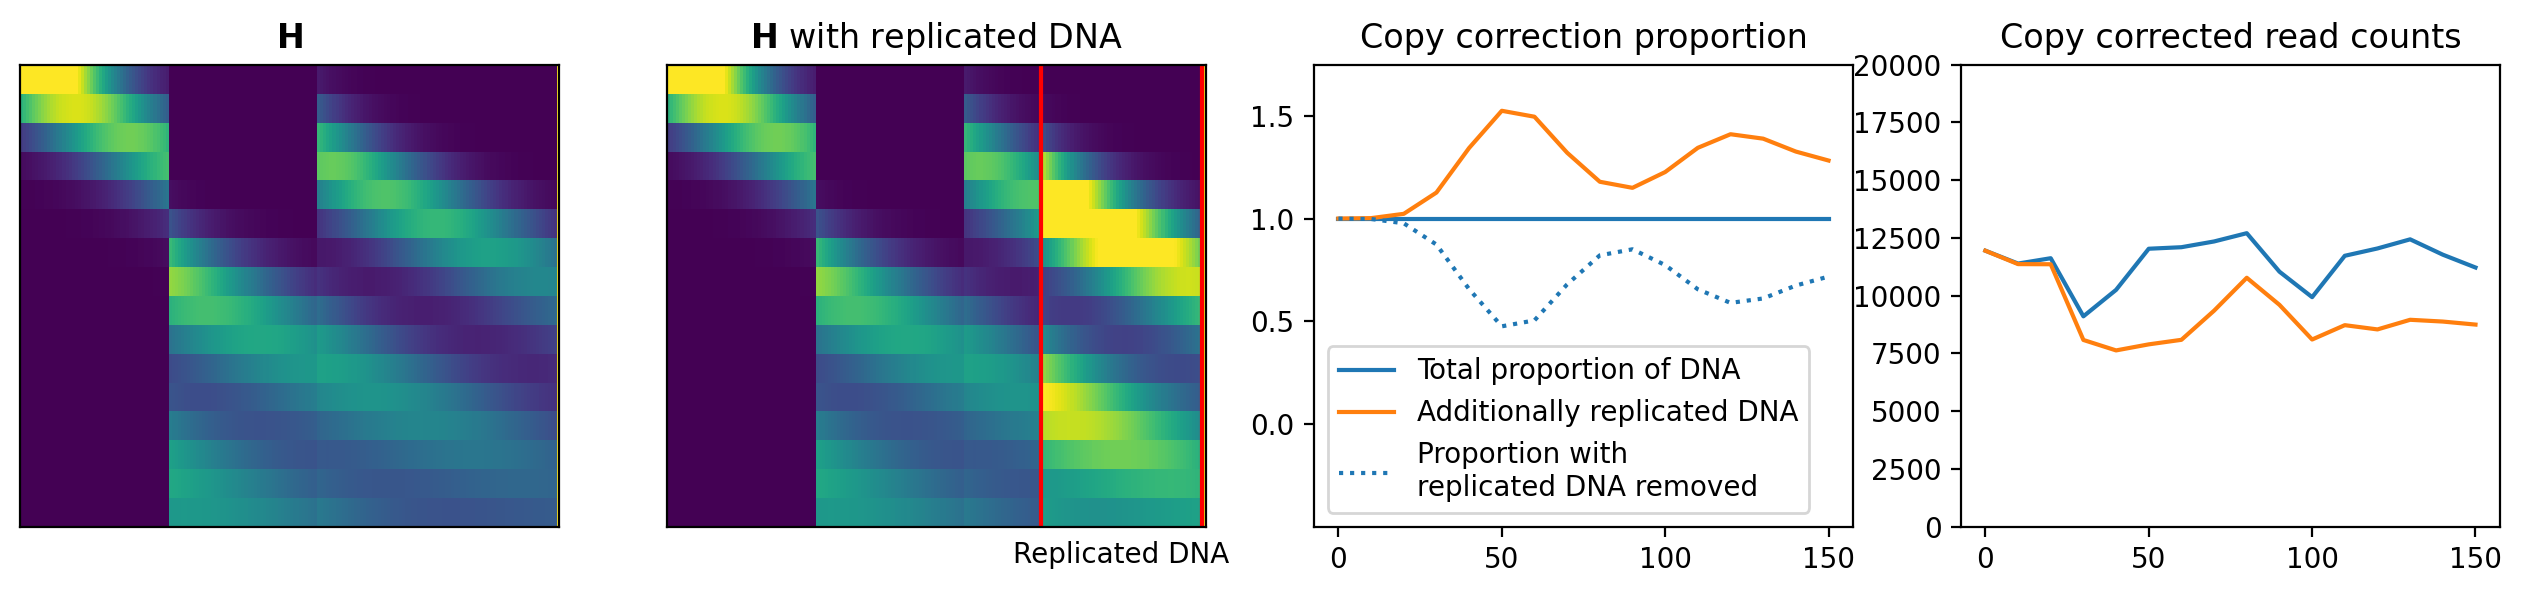

In [83]:
corrector.plot_correction_H()

In [96]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis
from src.timer import Timer
from src.global_config import GlobalConstants

# Idea: perform copy correction on the normalized 10k windows,
#       following copy correction, the occupancy values will have been reduced
#       and will need to be renormalized such that the total genome has an 
#       equal number of reads for timepoint

all_10k_windows = pd.read_csv('data/reference_data/sacCer3_genome_10k_windows.csv')\
    .set_index(['chr', 'start'])

genome_deconvolution = GenomeDeconvolution(save_dir=None)
corrector = CopyCorrector(genome_deconvolution)

timer = Timer()
tps1 = GlobalConstants.CHROM_WT1_TIMEPOINTS
tps2 = GlobalConstants.CHROM_WT2_TIMEPOINTS
    
# Keep track of the uncorrected and corrected 10k window sums
rep1_uncorrected = pd.DataFrame(index=all_10k_windows.index, columns=tps1)
rep1_corrected = pd.DataFrame(index=all_10k_windows.index, columns=tps1)
rep2_uncorrected = pd.DataFrame(index=all_10k_windows.index, columns=tps2)
rep2_corrected = pd.DataFrame(index=all_10k_windows.index, columns=tps2)

for chrom in range(1, 17):
    print(f"Chromosome {chrom}...")

    for start, row in all_10k_windows.loc[chrom].iterrows():

        end = row.end
        span = (start, end)
        genome_deconvolution.load_chrom_span(chrom, span, log=False)
        
        corrector.perform_correction(1)
        rep1_uncorrected.loc[chrom].loc[start] = corrector.uncorrected_reads_sum
        rep1_corrected.loc[chrom].loc[start] = corrector.corrected_reads_sum
        
        corrector.perform_correction(2)
        rep2_uncorrected.loc[chrom].loc[start] = corrector.uncorrected_reads_sum
        rep2_corrected.loc[chrom].loc[start] = corrector.corrected_reads_sum

    print("")
    timer.print_time()


Chromosome 1...
Could not retrieve replication profile for: 1, (230000, 230218)
Applying no correction
Could not retrieve replication profile for: 1, (230000, 230218)
Applying no correction

00:01:56.849
Chromosome 2...
Could not retrieve replication profile for: 2, (810000, 813184)
Applying no correction
Could not retrieve replication profile for: 2, (810000, 813184)
Applying no correction

00:08:43.683
Chromosome 3...
Could not retrieve replication profile for: 3, (310000, 316620)
Applying no correction
Could not retrieve replication profile for: 3, (310000, 316620)
Applying no correction

00:11:14.638
Chromosome 4...
Could not retrieve replication profile for: 4, (1530000, 1531933)
Applying no correction
Could not retrieve replication profile for: 4, (1530000, 1531933)
Applying no correction

00:23:37.148
Chromosome 5...
Could not retrieve replication profile for: 5, (570000, 576874)
Applying no correction
Could not retrieve replication profile for: 5, (570000, 576874)
Applying no c

In [136]:
# Normalize the correction data such that all samples are equal in total read count

def normalize_read_counts(rep1_corrected):
    TOTAL_COUNTS_PER_TIME = 15000000
    rep1_corrected.sum(axis=0).values.reshape((-1, 1))
    rep1_corrected_normalized = rep1_corrected.copy()
    rep1_corrected_normalized.loc[:] = rep1_corrected.values / \
        rep1_corrected.sum(axis=0).values.reshape((1, -1))
    return rep1_corrected_normalized * TOTAL_COUNTS_PER_TIME

rep1_corrected_normalized = normalize_read_counts(rep1_corrected)
rep2_corrected_normalized = normalize_read_counts(rep2_corrected)

In [188]:
rep1_corection_normalization_scalar = (rep1_corrected_normalized+1) / (rep1_uncorrected+1)
rep2_corection_normalization_scalar = (rep2_corrected_normalized+1) / (rep2_uncorrected+1)

In [203]:
rep1_corection_normalization_scalar.to_csv('data/copy_correction/chromatin/copy_correction_replicate1.csv')
rep2_corection_normalization_scalar.to_csv('data/copy_correction/chromatin/copy_correction_replicate2.csv')

In [157]:
sorted_index = corrector.chrom_replication_profile.join(rep1_uncorrected[[]], how='inner')\
    .sort_values('replication_index').index

([], [])

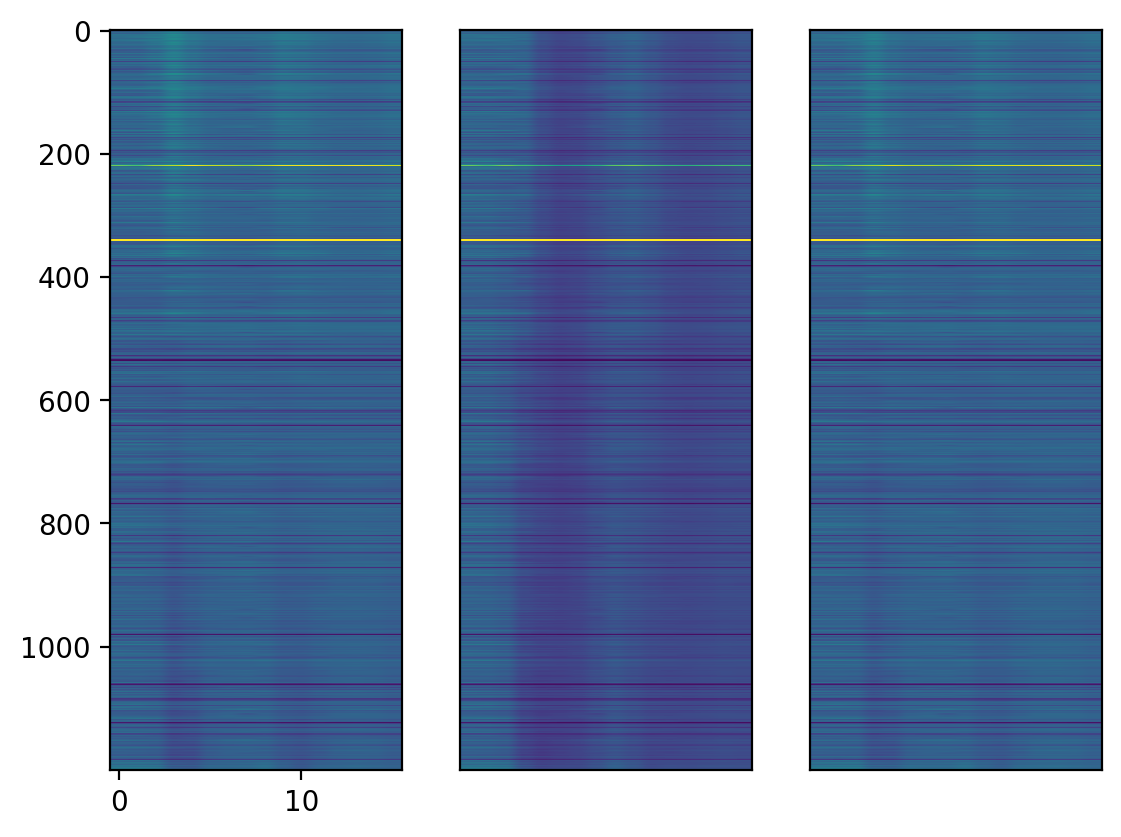

In [159]:
plt.subplot(1, 3, 1)
plt.imshow(rep1_uncorrected.astype(float).loc[sorted_index], 
           aspect='auto', vmin=0, vmax=40000)

plt.subplot(1, 3, 2)
plt.imshow(rep1_corrected.astype(float).loc[sorted_index],
           aspect='auto', vmin=0, vmax=40000)
plt.yticks([])
plt.xticks([])

plt.subplot(1, 3, 3)
plt.imshow(rep1_corrected_normalized.astype(float).loc[sorted_index], 
           aspect='auto', vmin=0, vmax=40000)
plt.yticks([])
plt.xticks([])

Text(0.5, 1.0, 'Late replication example')

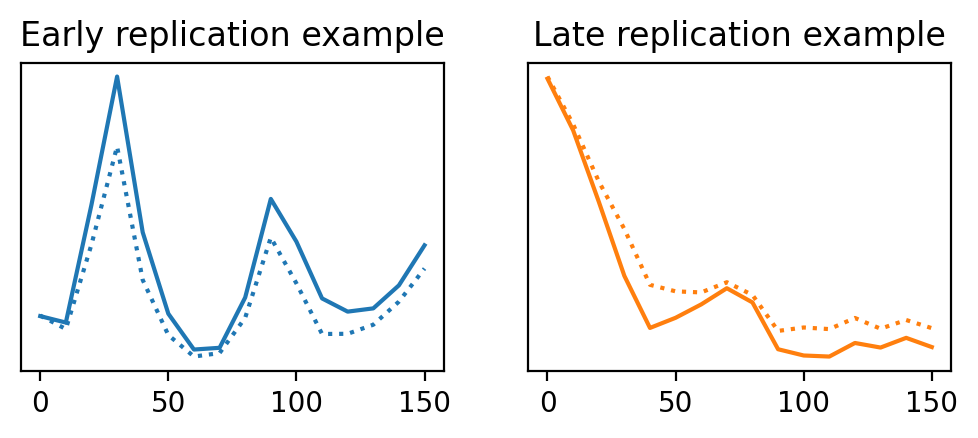

In [181]:
early_color = plt.get_cmap('tab10')(0)
late_color = plt.get_cmap('tab10')(1)

plt.figure(figsize=(6, 2))
plt.subplot(1, 2, 1)
plt.plot(rep1_uncorrected.loc[sorted_index].iloc[0], c=early_color)
plt.plot(rep1_corrected_normalized.loc[sorted_index].iloc[0], c=early_color, 
        ls='dotted')
plt.yticks([])
plt.title("Early replication example")

plt.subplot(1, 2, 2)
plt.plot(rep1_uncorrected.loc[sorted_index].iloc[-1], c=late_color)
plt.plot(rep1_corrected_normalized.loc[sorted_index].iloc[-1], c=late_color,
        ls='dotted')
plt.yticks([])
plt.title("Late replication example")


In [216]:
from src.peak_to_trough import compute_quantile_ptr_2d

# Let's check the PTR adjustment

rep1_uncorrected_ptr = compute_quantile_ptr_2d(
    rep1_uncorrected, hi=0.9, lo=0.1)
rep1_corrected_normed_ptr = compute_quantile_ptr_2d(
    rep1_corrected_normalized, hi=0.9, lo=0.1)

Text(0.5, 1.0, 'PTR change')

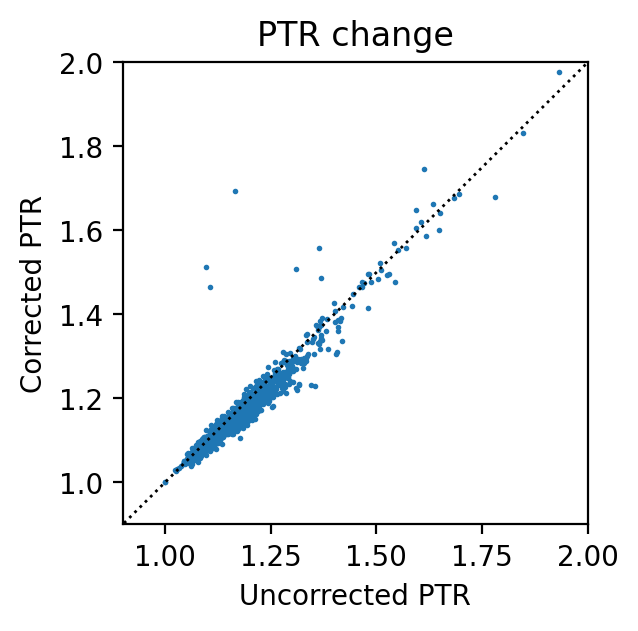

In [217]:
plt.figure(figsize=(3, 3))
plt.scatter(rep1_uncorrected_ptr, rep1_corrected_normed_ptr, s=1)
plt.plot([0, 5], [0, 5], lw=1, ls='dotted', c='black')
plt.xlim(0.9, 2)
plt.ylim(0.9, 2)
plt.xlabel("Uncorrected PTR")
plt.ylabel("Corrected PTR")
plt.title("PTR change")

In [220]:
chr, span = corrector.genome_deconvolution.combined_model.chrom1_model.chr, \
    corrector.genome_deconvolution.combined_model.chrom1_model.mnase_span

In [223]:
from src.copy_correction_reanalysis import perform_precomputed_correction_normalisation

corrected_normalized_bins = perform_precomputed_correction_normalisation(
    corrector.genome_deconvolution.combined_model.chrom1_model.normalized_bins,
    chrom, span, 1)

In [224]:
corrected_normalized_bins.sum(axis=1).sum(axis=1)

array([5911.97345043, 5762.80481536, 5712.17998765, 8281.77978483,
       8532.82644215, 8920.49928513, 9161.19695984, 6305.63672289,
       6570.2993496 , 6512.71891409, 6905.48048688, 7505.36084691,
       6838.56065536, 6619.78742214, 6210.45583108, 6451.54247688])

In [235]:
genome_deconvolution.load_chrom_span(1, (30000, 40000))

Loading chromosome reads: 1
Applying a normalization for length distribution
Loading chromosome reads: 1
Applying a normalization for length distribution


In [ ]:
genome_deconvolution.deconvolve()

Deconvolving combined model with gamma=0.0066
Deconvolving bin size: 10x10
of G shape: (31, 26000)
Deconvolving with gamma=0.0066
0/26000 - 00:00:00.140
500/26000 - 00:00:33.789
1000/26000 - 00:01:08.589
1500/26000 - 00:01:43.460
2000/26000 - 00:02:17.342
2500/26000 - 00:02:50.971
3000/26000 - 00:03:24.603
3500/26000 - 00:03:58.257
4000/26000 - 00:04:31.973
4500/26000 - 00:05:05.085
5000/26000 - 00:05:38.903
